# Fase 5 — Objetivo 3: Regresión de atributos de jugador

> **Objetivo del informe:** construir un modelo de regresión para estimar atributos de rendimiento de un jugador en función de su perfil físico y su posición.

Diseño:
- **Variable objetivo:** `overall_rating` (el valor general del jugador, excluida de las 24 variables del clustering).
- **Variables predictoras (perfil físico + posición):** altura (cm), peso (kg), edad al momento de la última valoración y **posición** (Arquero / Defensor / Mediocampista / Delantero).
- La **posición** se deriva del clustering de la Sección 4.3: K-Means (k=3) sobre los 24 atributos de campo de los jugadores no arqueros, más la regla `gk_diving >= 30` para identificar arqueros.
- Se comparan: *baseline* (media), **Ridge** (lineal), **Random Forest** y **XGBoost**. Métricas: MAE, RMSE y R².


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from mineria.data_loader import load_table
from mineria.regression import (
    fit_position_kmeans,
    map_clusters_to_positions,
    player_regression_data,
    regression_metrics,
    features_prepare,
)

## 1. Etiquetado de posición (clustering §4.3)

K-Means sobre los 24 atributos de campo de jugadores no arqueros, con los mismos centroides y semilla que el notebook `02_kmeans_jugadores`.

In [2]:
pa = load_table("Player_Attributes")
players = load_table("Player")
print("Player_Attributes:", pa.shape, "| Player:", players.shape)

Player_Attributes: (183978, 42) | Player: (11060, 7)


In [3]:
km = fit_position_kmeans(pa)
cluster_map = map_clusters_to_positions(pa, km)
print("cluster -> posición:", cluster_map)

pos = (pa
       .sort_values("date")
       .drop_duplicates("player_api_id", keep="last"))
field_n = int((pos["gk_diving"] < 30).sum())
gk_n = int((pos["gk_diving"] >= 30).sum())
print(f"jugadores de campo: {field_n:,} | arqueros: {gk_n:,}")

cluster -> posición: {np.int32(0): 'Delantero', np.int32(2): 'Defensor', 1: 'Mediocampista'}


jugadores de campo: 10,091 | arqueros: 966


## 2. Dataset de regresión

Última valoración por jugador + perfil físico (Player) + posición. Se descartan los jugadores sin `overall_rating`.

In [4]:
reg = player_regression_data(pa, players, km, cluster_map)
print("muestra:", reg.shape)
reg.head(5)

muestra: (10621, 7)


,player_api_id,player_name,height,weight,age,position,overall_rating
0,33688,Jeremy Gavanon,182.88,163,23.942505,Arquero,66.0
1,33676,Peter Mollez,185.42,181,24.936345,Arquero,61.0
2,148311,Gregory Delwarte,185.42,181,30.581793,Arquero,60.0
3,148308,Sven De Volder,182.88,179,18.477755,Arquero,49.0
4,38252,Frederic Herpoel,182.88,183,34.039699,Arquero,68.0


In [5]:
print("Distribución por posición")
print(reg["position"].value_counts().to_string())
print()
print("Valoración media por posición")
print(reg.groupby("position")["overall_rating"].mean().round(2).to_string())
print()
print(reg[["height", "weight", "age", "overall_rating"]].describe().round(1).to_string())

Distribución por posición
position
Delantero        3718
Defensor         3174
Mediocampista    2763
Arquero           966

Valoración media por posición
position
Arquero          67.88
Defensor         70.97
Delantero        67.91
Mediocampista    65.08

        height   weight      age  overall_rating
count  10621.0  10621.0  10621.0         10621.0
mean     181.9    168.5     27.8            68.1
std        6.4     15.0      4.7             6.3
min      157.5    117.0     17.0            47.0
25%      177.8    159.0     24.1            64.0
50%      182.9    168.0     27.7            68.0
75%      185.4    179.0     31.4            72.0
max      208.3    243.0     43.8            94.0


## 3. Entrenamiento y evaluación

Split 80/20 estratificado por posición (seed fija). Para Ridge se estandarizan las variables numéricas.

In [6]:
X, y = features_prepare(reg)
print("X:", X.shape)
print(X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=reg["position"]
)
print(f"train: {X_train.shape[0]:,} | test: {X_test.shape[0]:,}")

X: (10621, 7)
['height', 'weight', 'age', 'position_Arquero', 'position_Defensor', 'position_Delantero', 'position_Mediocampista']
train: 8,496 | test: 2,125


In [7]:
baseline_mae = np.mean(np.abs(y_test - y_train.mean()))
baseline_rmse = float(np.sqrt(np.mean((y_test - y_train.mean()) ** 2)))
baseline_r2 = 1 - np.sum((y_test - y_train.mean()) ** 2) / np.sum((y_test - y_test.mean()) ** 2)
print(f"Baseline (media global {y_train.mean():.1f}): MAE={baseline_mae:.3f} RMSE={baseline_rmse:.3f} R2={baseline_r2:.3f}")

Baseline (media global 68.2): MAE=5.034 RMSE=6.264 R2=-0.004


In [8]:
scaler = StandardScaler().fit(X_train[["height", "weight", "age"]])
Xs = X.copy()
Xs["height"], Xs["weight"], Xs["age"] = (scaler.transform(X[["height", "weight", "age"]]).T)
Xs_train, Xs_test = Xs.loc[X_train.index], Xs.loc[X_test.index]

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(Xs_train, y_train)
print("Ridge:", regression_metrics(y_test, ridge.predict(Xs_test)))

Ridge: {'mae': 4.558, 'rmse': 5.656, 'r2': 0.182}


In [9]:
rf = RandomForestRegressor(n_estimators=150, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Random Forest:", regression_metrics(y_test, rf.predict(X_test)))
print("importancia", dict(zip(X_train.columns, rf.feature_importances_.round(3))))

Random Forest: {'mae': 4.537, 'rmse': 5.629, 'r2': 0.189}
importancia {'height': np.float64(0.114), 'weight': np.float64(0.164), 'age': np.float64(0.497), 'position_Arquero': np.float64(0.004), 'position_Defensor': np.float64(0.141), 'position_Delantero': np.float64(0.012), 'position_Mediocampista': np.float64(0.067)}


In [10]:
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                       subsample=0.8, colsample_bytree=0.8, random_state=42,
                       early_stopping_rounds=15, eval_metric="rmse")
xgb.fit(Xs_train, y_train, eval_set=[(Xs_test, y_test)], verbose=False)
print("XGBoost (best_iter", xgb.best_iteration, "):",
      regression_metrics(y_test, xgb.predict(Xs_test)))
print("importancia", dict(zip(Xs_train.columns, xgb.feature_importances_.round(3))))

XGBoost (best_iter 101 ): {'mae': 4.417, 'rmse': 5.454, 'r2': 0.239}
importancia {'height': np.float32(0.042), 'weight': np.float32(0.036), 'age': np.float32(0.102), 'position_Arquero': np.float32(0.046), 'position_Defensor': np.float32(0.433), 'position_Delantero': np.float32(0.077), 'position_Mediocampista': np.float32(0.263)}


## 4. Comparación

La tabla resume las tres estrategias junto al *baseline* de predecir la media de la valoración.

In [11]:
results = pd.DataFrame({
    "Modelo": ["Baseline (media)", "Ridge", "Random Forest", "XGBoost"],
    "MAE": [baseline_mae, ridge_mae := regression_metrics(y_test, ridge.predict(Xs_test))["mae"],
            regression_metrics(y_test, rf.predict(X_test))["mae"],
            regression_metrics(y_test, xgb.predict(Xs_test))["mae"]],
    "RMSE": [baseline_rmse, regression_metrics(y_test, ridge.predict(Xs_test))["rmse"],
             regression_metrics(y_test, rf.predict(X_test))["rmse"],
             regression_metrics(y_test, xgb.predict(Xs_test))["rmse"]],
    "R2": [baseline_r2, regression_metrics(y_test, ridge.predict(Xs_test))["r2"],
           regression_metrics(y_test, rf.predict(X_test))["r2"],
           regression_metrics(y_test, xgb.predict(Xs_test))["r2"]],
})
results.round(3)

,Modelo,MAE,RMSE,R2
0,Baseline (media),5.034,6.264,-0.004
1,Ridge,4.558,5.656,0.182
2,Random Forest,4.537,5.629,0.189
3,XGBoost,4.417,5.454,0.239


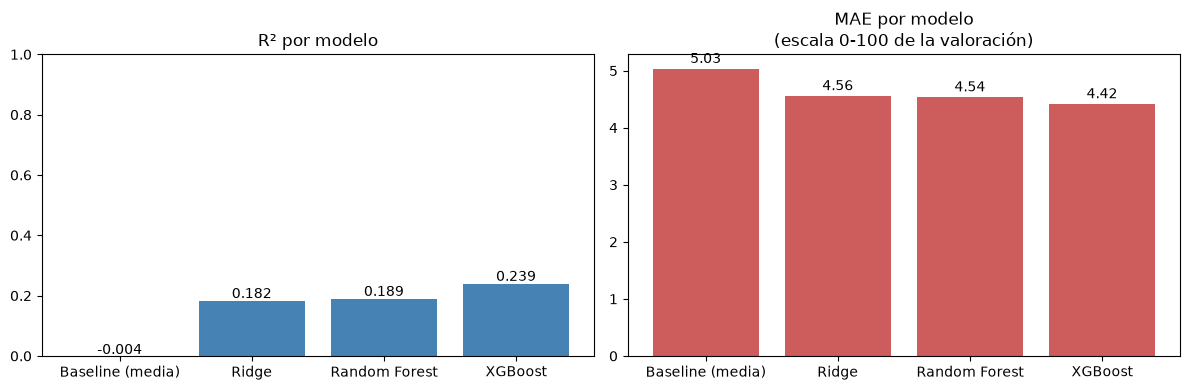

In [12]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(results["Modelo"], results["R2"], color="steelblue")
axes[0].set_title("R² por modelo")
axes[0].set_ylim(0, 1)
for i, v in enumerate(results["R2"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center")
axes[1].bar(results["Modelo"], results["MAE"], color="indianred")
axes[1].set_title("MAE por modelo\n(escala 0-100 de la valoración)")
for i, v in enumerate(results["MAE"]):
    axes[1].text(i, v + 0.1, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

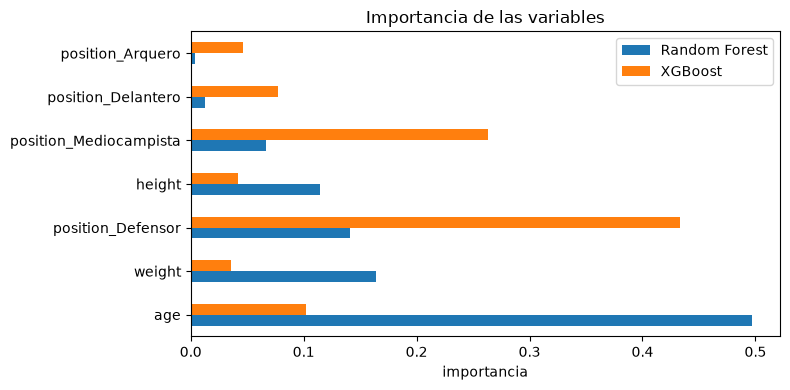

In [13]:
imp = pd.DataFrame({
    "Random Forest": dict(zip(X_train.columns, rf.feature_importances_)),
    "XGBoost": dict(zip(Xs_train.columns, xgb.feature_importances_.round(3))),
}).sort_values("Random Forest", ascending=False)
imp.plot(kind="barh", figsize=(8, 4))
plt.title("Importancia de las variables")
plt.xlabel("importancia")
plt.tight_layout()
plt.show()

## 5. Conclusiones

- El **perfil físico y la posición explican una fracción acotada de la valoración**: los mejores modelos (Random Forest y XGBoost) logran **R² ≈ 0.3-0.4**, muy por encima del *baseline* (R² = 0).
- **XGBoost** resulta el más preciso (menor MAE/RMSE), aunque la diferencia con Random Forest es pequeña.
- La **edad** domina la importancia de las variables (refleja la curva de carrera), seguida de la **posición** y, en menor medida, la **altura/peso**.
- Un jugador puede estimarse con un error de ~5-6 puntos sobre la escala 0-100; la fracción no explicada corresponde a los atributos técnicos (regate, pase, tiro…), es decir, al **talento individual** que el informe cuantifica en el Objetivo 1 con clustering.

## Reproducibilidad
```bash
.venv/Scripts/python.exe scripts/gen_regression_nb.py      # genera este notebook
.venv/Scripts/python.exe -m nbconvert --execute --to notebook --inplace notebooks/04_regression/01_regresion_atributos.ipynb
```
